# Experiment: NAVI on Custom H5AD

Objective:
- Train NAVI on your own Xenium `.h5ad` dataset.
- Extract `X_z_cell`, `X_z_spatial`, and `X_z_joint` embeddings into `.obsm`.
- Save a new `.h5ad` that includes latent embeddings.


In [1]:
# Setup
from __future__ import annotations

from pathlib import Path

import scanpy as sc
import torch

from navi import NAVI

SEED = 7
torch.manual_seed(SEED)

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd().resolve())

# Update this path to your own file before running.
DATA_PATH = Path("/Users/christoffer/work/karolinska/development/baloMS/data/baloMS-nuclei-clustered-balo.h5ad")
OUTPUT_PATH = PROJECT_ROOT / "output/jupyter-notebook/navi-custom-h5ad-with-latents.h5ad"
METRICS_PATH = PROJECT_ROOT / "output/jupyter-notebook/navi-custom-h5ad-latent-metrics.csv"

assert DATA_PATH.exists(), f"Missing input file: {DATA_PATH}"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f"Input: {DATA_PATH}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Output h5ad: {OUTPUT_PATH.resolve()}")
print(f"Output metrics: {METRICS_PATH.resolve()}")
print(f"CUDA available: {torch.cuda.is_available()}")


/Users/christoffer/miniconda3/envs/NAVI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input: /Users/christoffer/work/karolinska/development/baloMS/data/baloMS-nuclei-clustered-balo.h5ad
Project root: /Users/christoffer/work/karolinska/development/NAVI
Output h5ad: /Users/christoffer/work/karolinska/development/NAVI/output/jupyter-notebook/navi-custom-h5ad-with-latents.h5ad
Output metrics: /Users/christoffer/work/karolinska/development/NAVI/output/jupyter-notebook/navi-custom-h5ad-latent-metrics.csv
CUDA available: False


In [2]:
# Load and validate AnnData schema expected by NAVI
adata = sc.read_h5ad(DATA_PATH)
print(adata)

required_obs = {"sample_id"}
missing_obs = sorted(required_obs - set(adata.obs.columns))
if missing_obs:
    raise KeyError(f"Missing required obs columns: {missing_obs}")

if "spatial" not in adata.obsm:
    raise KeyError("Missing required obsm['spatial'] coordinates")

counts_source = "layers['counts']" if "counts" in adata.layers else "X"
print("Counts source:", counts_source)
print("Samples:", adata.obs['sample_id'].nunique())
adata.obs['sample_id'].value_counts().head()


AnnData object with n_obs × n_vars = 64191 × 4907
    obs: 'cell_id_orig', 'x_centroid', 'y_centroid', 'nucleus_area', 'n_genes_by_counts', 'total_counts', 'n_counts', 'sample_id', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'gmm_mana_5', 'gmm_mana_8', 'gmm_mana_10', 'gmm_mana_12', 'gmm_mana_15', 'gmm_mana_20', 'gmm_mana_30'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'X_mana_gauss_params', 'gmm_mana_10_colors', 'gmm_mana_20_colors', 'gmm_mana_30_colors', 'gmm_mana_5_colors', 'gmm_mana_8_colors', 'hvg', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1', 'leiden_1.5', 'leiden_1.5_colors', 'leiden_1_colors', 'leiden_2', 'leiden_2.5', 'leiden_2.5_colors', 'leiden_2_colors', 'leiden_3', 'leiden_3.5', 'leiden_3.5_colors', 'leiden_3_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial_neighbors', 'umap'
    obsm: 'X_mana_gauss', 'X_pca', 'X_scVI', 'X_umap', 'spatial'
    varm: 'PCs'
    

sample_id
Balo-2    36776
Balo-1    27415
Name: count, dtype: int64

## Train NAVI

Start with conservative settings. Increase `max_epochs` once the first run succeeds.


In [3]:
# Integration-first training config for z_joint
if torch.backends.mps.is_available():
    accelerator = "mps"
elif torch.cuda.is_available():
    accelerator = "gpu"
else:
    accelerator = "cpu"

# Choose a shared FiLM group for integration (avoid per-sample FiLM by default).
if "condition" in adata.obs.columns:
    adata.obs["film_group"] = adata.obs["condition"].astype(str)
elif "timepoint" in adata.obs.columns:
    adata.obs["film_group"] = adata.obs["timepoint"].astype(str)
else:
    adata.obs["film_group"] = "global"
film_key = "film_group"

print("Accelerator:", accelerator)
print("FiLM conditioning key:", film_key)
print("FiLM groups:", adata.obs[film_key].value_counts().to_dict())

model = NAVI(
    sample_key="sample_id",
    film_key=film_key,
    spatial_key="spatial",
    counts_layer="counts",
    k_neighbors=15,
    n_latent_cell=32,
    n_latent_spatial=32,
    training_mode="joint",
    normalize_recon_by_genes=False,
    # Keep z_cell sample-invariant
    lambda_adv=1.0,
    # New: push z_joint toward sample invariance too
    lambda_adv_joint=0.0,
    # New: prevent FiLM from over-personalizing each sample
    lambda_film_reg=1e-2,
    # New: soften FiLM strength (0=no FiLM, 1=full FiLM)
    film_scale=0.3,
    # Slightly downweight spatial KL so spatial term does not dominate early.
    beta2=0.5,
    kl_warmup_epochs=5,
    kl_ramp_epochs=20,
    max_epochs=60,
    accelerator=accelerator,
    devices=1,
    seed=SEED,
)

model.fit(adata)
latents = model.get_latent(adata)
{name: arr.shape for name, arr in latents.items()}


Accelerator: mps
FiLM conditioning key: film_group
FiLM groups: {'global': 64191}


Seed set to 7


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ cell_encoder         │ CellEncoder         │  1.3 M │ train │     0 │
│ 1 │ spatial_encoder      │ SpatialEncoder      │ 54.6 K │ train │     0 │
│ 2 │ sample_embedding     │ SampleEmbedding     │  1.1 K │ train │     0 │
│ 3 │ decoder              │ NBDecoder           │  647 K │ train │     0 │
│ 4 │ gradient_reversal    │ GradientReversal    │      0 │ train │     0 │
│ 5 │ sample_discriminator │ SampleDiscriminator │ 12.6 K │ train │     0 │
│ 6 │ joint_discriminator  │ SampleDiscriminator │ 16.7 K │ train │     0 │
└───┴──────────────────────┴─────────────────────┴────────┴───────┴───────┘

...

/Users/christoffer/miniconda3/envs/NAVI/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/christoffer/miniconda3/envs/NAVI/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/Users/christoffer/miniconda3/envs/NAVI/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:79: Trying
to infer the `batch_size` from an ambiguous collection. The batch size we found is 64191. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=60` reached.


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


{'z_cell': (64191, 32), 'z_spatial': (64191, 32), 'z_joint': (64191, 64)}

In [4]:
import numpy as np
corr = np.corrcoef(latents['z_cell'].flatten(), latents['z_spatial'].flatten())[0,1]
print(f"Correlation z_cell vs z_spatial: {corr:.3f}")
# Should be well below 1.0 — if it's >0.95 something is wrong

Correlation z_cell vs z_spatial: 0.010


## Analysis: Embedding quality checks

Compute UMAPs for each latent space and quantify sample/condition/timepoint mixing.


In [5]:
# Build neighbor graphs and UMAP coordinates for each latent space
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

latent_map = {
    "z_cell": "X_z_cell",
    "z_spatial": "X_z_spatial",
    "z_joint": "X_z_joint",
}

for latent_name, obsm_key in latent_map.items():
    neighbors_key = f"neighbors_{latent_name}"
    umap_key = f"X_umap_{latent_name}"
    sc.pp.neighbors(adata, use_rep=obsm_key, n_neighbors=15, key_added=neighbors_key)
    sc.tl.umap(adata, neighbors_key=neighbors_key)
    adata.obsm[umap_key] = adata.obsm["X_umap"].copy()

print("Stored UMAP keys:", [f"X_umap_{k}" for k in latent_map])


Stored UMAP keys: ['X_umap_z_cell', 'X_umap_z_spatial', 'X_umap_z_joint']


In [6]:
# Quantify mixing/separation in each latent space
def knn_mixing_score(embedding: np.ndarray, labels: np.ndarray, k: int = 30) -> float:
    k_eff = min(k, embedding.shape[0] - 1)
    if k_eff < 1:
        return float("nan")
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric="euclidean")
    nn.fit(embedding)
    neigh_idx = nn.kneighbors(return_distance=False)[:, 1:]
    return float((labels[neigh_idx] != labels[:, None]).mean())

label_columns = [c for c in ["sample_id", "condition", "timepoint"] if c in adata.obs.columns]
rng = np.random.default_rng(SEED)
metrics_rows = []

for latent_name, obsm_key in latent_map.items():
    embedding = np.asarray(adata.obsm[obsm_key], dtype=np.float32)
    for label_col in label_columns:
        labels = adata.obs[label_col].astype(str).to_numpy()
        n_unique = np.unique(labels).size
        row = {
            "latent": latent_name,
            "label": label_col,
            "n_classes": int(n_unique),
            "mixing_k30_higher_is_better": knn_mixing_score(embedding, labels, k=30),
            "silhouette_lower_is_better_for_mixing": np.nan,
        }
        if n_unique > 1:
            n_eval = min(10000, embedding.shape[0])
            eval_idx = rng.choice(embedding.shape[0], size=n_eval, replace=False)
            row["silhouette_lower_is_better_for_mixing"] = float(
                silhouette_score(embedding[eval_idx], labels[eval_idx], metric="euclidean")
            )
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).sort_values(["label", "latent"]).reset_index(drop=True)
metrics_df


,latent,label,n_classes,mixing_k30_higher_is_better,silhouette_lower_is_better_for_mixing
0,z_cell,sample_id,2,0.095141,0.095310
1,z_joint,sample_id,2,0.117868,0.106893
2,z_spatial,sample_id,2,0.029523,0.190721


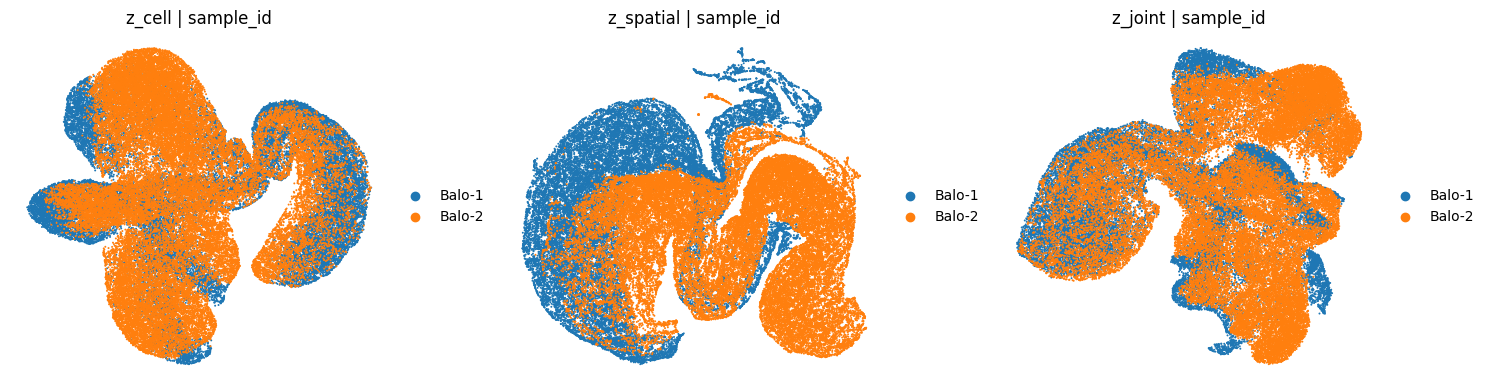

In [7]:
# Visualize UMAPs colored by sample/condition/timepoint (if present)
plot_labels = [c for c in ["sample_id", "condition", "timepoint"] if c in adata.obs.columns]
if not plot_labels:
    plot_labels = ["sample_id"]

bases = [(name, f"umap_{name}") for name in latent_map]
fig, axes = plt.subplots(
    nrows=len(plot_labels),
    ncols=len(bases),
    figsize=(5 * len(bases), 4 * len(plot_labels)),
    squeeze=False,
)

for r, color in enumerate(plot_labels):
    for c, (latent_name, basis) in enumerate(bases):
        ax = axes[r, c]
        sc.pl.embedding(
            adata,
            basis=basis,
            color=color,
            ax=ax,
            show=False,
            frameon=False,
            title=f"{latent_name} | {color}",
            size=8,
        )
plt.tight_layout()


In [8]:
bases = [(name, f"umap_{name}") for name in latent_map]

In [9]:
bases

[('z_cell', 'umap_z_cell'),
 ('z_spatial', 'umap_z_spatial'),
 ('z_joint', 'umap_z_joint')]

<Axes: title={'center': 'umap_z_spatial | leiden'}, xlabel='umap_z_spatial1', ylabel='umap_z_spatial2'>

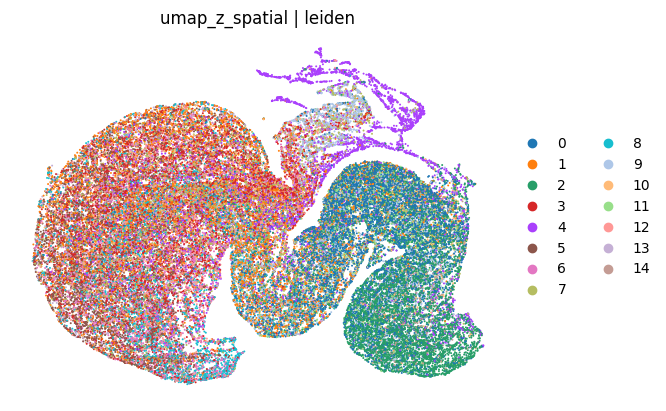

In [10]:
basis='umap_z_spatial'
sc.pl.embedding(
        adata,
        basis=basis,
        color='leiden_1',
        show=False,
        frameon=False,
        title=f"{basis} | {'leiden'}",
        size=8,
    )

In [11]:
basis

'umap_z_spatial'

In [12]:
# Confirm latent matrices and write result artifacts
print([k for k in adata.obsm.keys() if k.startswith("X_z_")])
print("Graph metadata:", model.graph_metadata_)

adata.write_h5ad(OUTPUT_PATH)
print(f"Saved h5ad: {OUTPUT_PATH.resolve()}")

if "metrics_df" in locals() and not metrics_df.empty:
    metrics_df.to_csv(METRICS_PATH, index=False)
    print(f"Saved metrics: {METRICS_PATH.resolve()}")


['X_z_cell', 'X_z_spatial', 'X_z_joint']
Graph metadata: {'adjusted_k_per_sample': {np.str_('Balo-1'): 15, np.str_('Balo-2'): 15}, 'skipped_samples': []}
Saved h5ad: /Users/christoffer/work/karolinska/development/NAVI/output/jupyter-notebook/navi-custom-h5ad-with-latents.h5ad
Saved metrics: /Users/christoffer/work/karolinska/development/NAVI/output/jupyter-notebook/navi-custom-h5ad-latent-metrics.csv


## aggregate neighbors and run GMM

In [13]:
import squidpy as sq
import cellcharter as cc

In [14]:
sq.gr.spatial_neighbors(adata, library_key='sample_id', coord_type='generic', delaunay=True)

INFO     Creating graph using `generic` coordinates and `None` transform and `2` libraries.                        


In [15]:
cc.gr.remove_long_links(adata)

In [16]:
adata

AnnData object with n_obs × n_vars = 64191 × 4907
    obs: 'cell_id_orig', 'x_centroid', 'y_centroid', 'nucleus_area', 'n_genes_by_counts', 'total_counts', 'n_counts', 'sample_id', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'gmm_mana_5', 'gmm_mana_8', 'gmm_mana_10', 'gmm_mana_12', 'gmm_mana_15', 'gmm_mana_20', 'gmm_mana_30', 'film_group'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'X_mana_gauss_params', 'gmm_mana_10_colors', 'gmm_mana_20_colors', 'gmm_mana_30_colors', 'gmm_mana_5_colors', 'gmm_mana_8_colors', 'hvg', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1', 'leiden_1.5', 'leiden_1.5_colors', 'leiden_1_colors', 'leiden_2', 'leiden_2.5', 'leiden_2.5_colors', 'leiden_2_colors', 'leiden_3', 'leiden_3.5', 'leiden_3.5_colors', 'leiden_3_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial_neighbors', 'umap', 'neighbors_z_cell', 'neighbors_z_spatial', 'neighbors_z_joint', 'sampl

In [22]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep = 'X_z_joint', out_key='agg_X_z_joint')

100%|██████████| 4/4 [00:00<00:00, 25.17it/s]


In [23]:
# GMM components to try
# GMM components to try
gmm_components = [10, 15]

In [24]:
from sklearn.mixture import GaussianMixture
import pandas as pd

X = adata.obsm['agg_X_z_joint']
gmm_results = []

for k in gmm_components:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=0,
        n_init=3,
    )
    labels = gmm.fit_predict(X)
    key = f'gmm_CC_{k}'
    adata.obs[key] = labels.astype(str)
    gmm_results.append({
        'k': k,
        'bic': gmm.bic(X),
        'aic': gmm.aic(X),
    })
    n_clusters = adata.obs[key].nunique()
    print(f'k={k}: {n_clusters} clusters')

k=10: 10 clusters
k=15: 15 clusters


In [25]:
import sys
sys.path.append("/Users/christoffer/work/karolinska/development/MANA")
from utils import aggregate_neighbors_weighted, plot_spatial_compact_fast

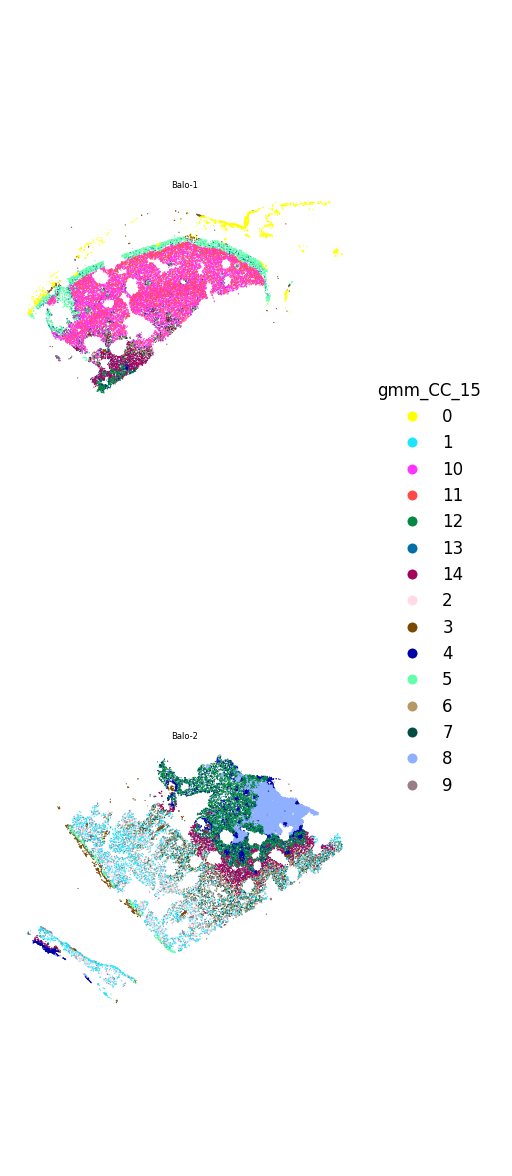

In [27]:
plot_spatial_compact_fast(
    adata,
    color="gmm_CC_15",
    groupby="sample_id",
    spot_size=0.5,
    cols=1,
    height=10,
    background="white",
    dpi=120,
)